In [1]:
print("all ok")

all ok


In [2]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [3]:
model="deepseek-r1-distill-llama-70b"

### Load the model

In [5]:
from langchain_groq import ChatGroq


In [7]:
llm=ChatGroq(model_name=model)

In [8]:
llm.invoke("hi")

AIMessage(content='<think>\n\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 4, 'total_tokens': 20, 'completion_time': 0.082161224, 'prompt_time': 5.5239e-05, 'queue_time': 0.22014220099999998, 'total_time': 0.082216463}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run-fac90160-de87-4818-bb68-1747f37dec8e-0', usage_metadata={'input_tokens': 4, 'output_tokens': 16, 'total_tokens': 20})

In [9]:
print(llm.invoke("hi").content)

<think>

</think>

Hello! How can I assist you today? 😊


In [11]:
# import operator
# from typing import List
# from langgraph.graph.message import add_messages
# from pydantic import BaseModel , Field
# from typing import TypedDict, Annotated, Sequence
# from langchain_core.messages import BaseMessage
# from langchain_core.output_parsers import StrOutputParser
# from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode

In [12]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

In [154]:
# HumanMessage("hi how are you?")

In [155]:
# HumanMessage(["hi how are you?"])

### this code is only for the testing

In [13]:

state={"messages":["hi hello how are you?"]}
call_model(state)

{'messages': [AIMessage(content="<think>\n\n</think>\n\nHello! I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you with whatever you need. How are you doing? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 9, 'total_tokens': 51, 'completion_time': 0.202980889, 'prompt_time': 0.000209106, 'queue_time': 0.21665335400000002, 'total_time': 0.203189995}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run-01d884bf-fd87-43e4-814b-404e8efb55de-0', usage_metadata={'input_tokens': 9, 'output_tokens': 42, 'total_tokens': 51})]}

In [ ]:
# from langchain_core.messages import AnyMessage
# # class MessagesState(TypedDict):
# #     messages: Annotated[list[AnyMessage], add_messages]


# class AgentState(TypedDict):
#     messages: Annotated[Sequence[BaseMessage], operator.add]

## Design a simple workflow without tool calling/

In [14]:
workflow=StateGraph(MessagesState)

In [15]:
workflow.add_node("mybot",call_model)

In [16]:
workflow.add_edge(START,"mybot")

In [17]:
workflow.add_edge("mybot",END)

In [18]:
app=workflow.compile()

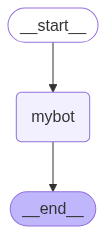

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
input={"messages":["hi hello how are you?"]}

In [21]:
app.invoke(input)

{'messages': [HumanMessage(content='hi hello how are you?', additional_kwargs={}, response_metadata={}, id='5caaa777-9bbd-4748-84d5-bca366102f38'),
  AIMessage(content="<think>\n\n</think>\n\nHello! I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you with whatever you need. How are you doing? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 9, 'total_tokens': 51, 'completion_time': 0.19420994, 'prompt_time': 0.000176967, 'queue_time': 0.217144499, 'total_time': 0.194386907}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run-822c93ce-82f8-48d9-83c2-0bc63aec258a-0', usage_metadata={'input_tokens': 9, 'output_tokens': 42, 'total_tokens': 51})]}

In [22]:
for output in app.stream(input):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from mybot Node
_______
{'messages': [AIMessage(content="<think>\n\n</think>\n\nHello! I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you with whatever you need. How are you doing? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 9, 'total_tokens': 51, 'completion_time': 0.187783651, 'prompt_time': 0.000180177, 'queue_time': 0.220993679, 'total_time': 0.187963828}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run-33e4f0b1-74a5-4025-85ad-045501de4ebb-0', usage_metadata={'input_tokens': 9, 'output_tokens': 42, 'total_tokens': 51})]}




### this is a workflow with tool calling

In [23]:
@tool
def search(query:str):
    """this is my custom tool for searching a weather"""
    if "delhi" in query.lower():
        return "the temp is 45 degree and sunny"
    return "the temp is 25 degree and cloudy"

## testing a tool

In [24]:
search.invoke("what is a tempurature in kashmir?")

'the temp is 25 degree and cloudy'

In [25]:
search.invoke("what is a tempurature in delhi?")

'the temp is 45 degree and sunny'

In [26]:
search

StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x111994cc0>)

In [27]:
llm.invoke("what is a weather in delhi?")

AIMessage(content="<think>\n\n</think>\n\nAs of my last update in July 2024, I cannot provide real-time weather information. However, I can give you an overview of Delhi's typical weather patterns:\n\n- **Summer (March to June):** Hot and humid, with temperatures often reaching 40°C (104°F) or higher.\n- **Monsoon (July to September):** Warm with heavy rainfall and high humidity.\n- **Winter (December to February):** Cool to cold, with temperatures ranging from 2°C (36°F) to 15°C (59°F).\n- **Autumn (October to November) and Spring (February to March):** Mild and pleasant, with temperatures between 10°C (50°F) and 25°C (77°F).\n\nFor the current weather in Delhi, I recommend checking a reliable weather service like AccuWeather, Weather.com, or the India Meteorological Department (IMD). Let me know if you'd like help with anything else!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 199, 'prompt_tokens': 11, 'total_tokens': 210, 'completion_time': 0.7236

### Binding a tool to the LLM

### Special Note: use some good for agentic workflow since opensource model might not give you the correct output

In [28]:
tools=[search]

In [29]:
llm_with_tool=llm.bind_tools(tools)

### testig my llm_with_tool

In [30]:
response=llm_with_tool.invoke("what is a weather is delhi?")

In [31]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'anq1gq5he', 'function': {'arguments': '{"query":"weather in Delhi"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 150, 'prompt_tokens': 133, 'total_tokens': 283, 'completion_time': 0.682048332, 'prompt_time': 0.008563499, 'queue_time': 0.216623776, 'total_time': 0.690611831}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-ac4c1b43-9842-493e-98e5-bd60bbdb2c9f-0', tool_calls=[{'name': 'search', 'args': {'query': 'weather in Delhi'}, 'id': 'anq1gq5he', 'type': 'tool_call'}], usage_metadata={'input_tokens': 133, 'output_tokens': 150, 'total_tokens': 283})

In [32]:
response.content

''

In [33]:
response.tool_calls

[{'name': 'search',
  'args': {'query': 'weather in Delhi'},
  'id': 'anq1gq5he',
  'type': 'tool_call'}]

In [34]:
def call_model(state:MessagesState):
    question=state["messages"]
    response=llm_with_tool.invoke(question)
    return {"messages":[response]}

### Testing code

In [36]:
input={"messages":["what is a weather in delhi?"]}

In [37]:
response=call_model(input)

In [38]:
response["messages"][-1].content

''

In [39]:
response["messages"][-1].tool_calls

[{'name': 'search',
  'args': {'query': 'weather in Delhi'},
  'id': '6frz1mrnn',
  'type': 'tool_call'}]

### here my router function

#### now whatever will come from call_model router funtion will redirect this to the appropriate tool

In [40]:
def router_function(state:MessagesState):
    message=state["messages"]
    last_message=message[-1]
    if last_message.tool_calls:
        return "tools"
    return END
    

In [41]:
tools

[StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x111994cc0>)]

In [42]:

tool_node=ToolNode(tools)

In [43]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts_config=True, func_accepts={'store': ('__pregel_store', None)}, tools_by_name={'search': StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x111994cc0>)}, tool_to_state_args={'search': {}}, tool_to_store_arg={'search': None}, handle_tool_errors=True, messages_key='messages')

In [44]:
workflow2=StateGraph(MessagesState)

In [45]:
workflow2.add_node("llmwithtool",call_model)

workflow2.add_node("mytools",tool_node)

workflow2.add_edge(START,"llmwithtool")

workflow2.add_conditional_edges("llmwithtool",
                                router_function,
                                {"tools":"mytools",
                                 END:END})

In [46]:
app2=workflow2.compile()

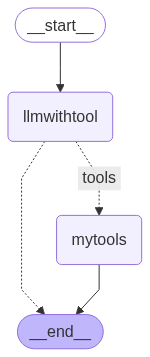

In [47]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [48]:
response=app2.invoke({"messages":["what is a weather in bengraluru?"]})

In [49]:
response["messages"][-1].content

'the temp is 25 degree and cloudy'

In [50]:
app2.invoke({"messages":["what is a weather in delhi?"]})

{'messages': [HumanMessage(content='what is a weather in delhi?', additional_kwargs={}, response_metadata={}, id='af13933d-52b1-4c1f-875c-26e49a3fdfdc'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'bpcpbjhpc', 'function': {'arguments': '{"query":"Delhi weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 223, 'prompt_tokens': 133, 'total_tokens': 356, 'completion_time': 1.048447884, 'prompt_time': 0.008549279, 'queue_time': 0.23762265800000001, 'total_time': 1.056997163}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-08a970e1-bd94-4707-82dc-dc74cb9cb8de-0', tool_calls=[{'name': 'search', 'args': {'query': 'Delhi weather'}, 'id': 'bpcpbjhpc', 'type': 'tool_call'}], usage_metadata={'input_tokens': 133, 'output_tokens': 223, 'total_tokens': 356}),
  ToolMessage(content='the temp is 45 degree and sunny', name='searc

### use good resoning based model

In [51]:
app2.invoke({"messages":["hi how are you?"]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='8e338490-fd32-4458-b10e-9bc17bff5cce'),
  AIMessage(content="Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 213, 'prompt_tokens': 130, 'total_tokens': 343, 'completion_time': 0.833869056, 'prompt_time': 0.008320394, 'queue_time': 0.22015533099999998, 'total_time': 0.84218945}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run-aa991582-d299-4f3f-b261-d19882c3925c-0', usage_metadata={'input_tokens': 130, 'output_tokens': 213, 'total_tokens': 343})]}

In [52]:
workflow2.add_edge("mytools","llmwithtool")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [53]:
app3=workflow2.compile()

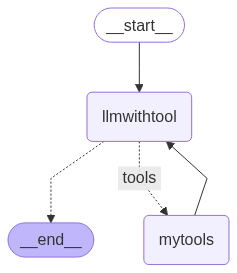

In [54]:
from IPython.display import Image, display
display(Image(app3.get_graph().draw_mermaid_png()))

In [55]:
for output in app3.stream({"messages":["what is a weather in new delhi?"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")
    

here is output from llmwithtool
_______
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'rmj38fpyw', 'function': {'arguments': '{"query":"weather in New Delhi"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 134, 'prompt_tokens': 134, 'total_tokens': 268, 'completion_time': 0.557469479, 'prompt_time': 0.00854481, 'queue_time': 0.231532336, 'total_time': 0.566014289}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-88fd3531-a88e-4589-8a36-54e68dc33ddd-0', tool_calls=[{'name': 'search', 'args': {'query': 'weather in New Delhi'}, 'id': 'rmj38fpyw', 'type': 'tool_call'}], usage_metadata={'input_tokens': 134, 'output_tokens': 134, 'total_tokens': 268})]}


here is output from mytools
_______
{'messages': [ToolMessage(content='the temp is 45 degree and sunny', name='search', id='31264bc0-5dcd-4025-a541-4b310dc6c99e',

In [56]:
"what is a weather in delhi can you tell me some good hotel for staying in north delhi"

'what is a weather in delhi can you tell me some good hotel for staying in north delhi'

In [57]:
from langgraph.checkpoint.memory import MemorySaver

In [58]:
memory=MemorySaver()

In [59]:
workflow3=StateGraph(MessagesState)

workflow3.add_node("llmwithtool",call_model)

workflow3.add_node("mytools",tool_node)

workflow3.add_edge(START,"llmwithtool")

workflow3.add_conditional_edges("llmwithtool",
                                router_function,
                                {"tools":"mytools",
                                 END:END})

workflow3.add_edge("mytools","llmwithtool")

In [60]:
app4=workflow3.compile(checkpointer=memory)

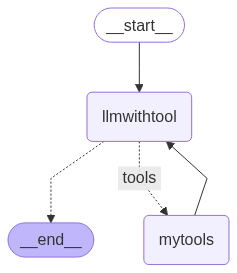

In [61]:
from IPython.display import Image, display
display(Image(app4.get_graph().draw_mermaid_png()))

In [62]:
config={"configurable": {"thread_id": "1"}}

In [63]:
events=app4.stream(
    {"messages":["what is a weather in new delhi?"]},config=config,stream_mode="values"
    )

In [64]:
for event in events:
    event["messages"][-1].pretty_print()
    

================================ Human Message =================================

what is a weather in new delhi?
================================== Ai Message ==================================
Tool Calls:
  search (j2dazh0yj)
 Call ID: j2dazh0yj
  Args:
    query: weather in New Delhi
================================= Tool Message =================================
Name: search

the temp is 45 degree and sunny
================================== Ai Message ==================================

It seems like you're confirming the weather conditions. If you have any further questions or need more details, feel free to ask!


In [65]:
events=app4.stream(
    {"messages":["what is a weather in indore?"]},config=config,stream_mode="values"
    )

In [67]:
config

{'configurable': {'thread_id': '1'}}

In [68]:
memory.get(config)

{'v': 3,
 'ts': '2025-06-15T02:47:10.776238+00:00',
 'id': '1f049930-8f4b-6e20-801e-99ecd1e0bb30',
 'channel_versions': {'__start__': '00000000000000000000000000000007.0.9568718096850013',
  'messages': '00000000000000000000000000000032.0.4556558883559777',
  'branch:to:llmwithtool': '00000000000000000000000000000032.0.6891492902644307',
  'branch:to:mytools': '00000000000000000000000000000032.0.02148670533766861'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000006.0.0329938044177539'},
  'llmwithtool': {'branch:to:llmwithtool': '00000000000000000000000000000031.0.41537477070254336'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000030.0.49350245183392727'}},
 'channel_values': {'messages': [HumanMessage(content='what is a weather in new delhi?', additional_kwargs={}, response_metadata={}, id='b7149ff7-0a5b-4568-8ecc-f3b1ba77b2aa'),
   AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'j2dazh0yj', 'function'

In [69]:
events=app4.stream(
    {"messages":["in which city the temp was 25 degree?"]},config=config,stream_mode="values"
    )

In [70]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

in which city the temp was 25 degree?
================================== Ai Message ==================================

The city where the temperature was 25 degrees is **Indore**, and it was cloudy.


In [71]:
memory.get(config)

{'v': 3,
 'ts': '2025-06-15T02:47:29.868040+00:00',
 'id': '1f049931-455e-6bfe-8021-a8c6f004342a',
 'channel_versions': {'__start__': '00000000000000000000000000000034.0.1339163158850979',
  'messages': '00000000000000000000000000000035.0.09087838458642705',
  'branch:to:llmwithtool': '00000000000000000000000000000035.0.10746714080403941',
  'branch:to:mytools': '00000000000000000000000000000033.0.41991630016944426'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000033.0.49547067894764385'},
  'llmwithtool': {'branch:to:llmwithtool': '00000000000000000000000000000034.0.2246274815235999'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000032.0.02148670533766861'}},
 'channel_values': {'messages': [HumanMessage(content='what is a weather in new delhi?', additional_kwargs={}, response_metadata={}, id='b7149ff7-0a5b-4568-8ecc-f3b1ba77b2aa'),
   AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'j2dazh0yj', 'functio